In [25]:
import numpy as np
import pandas as pd

In [ ]:
# data = pd.read_clipboard(
#     header=None,
#     names=["energy", "absorbance"]
# )
# display(data)
# data.to_csv("ps_100_40deg.csv")

,energy,absorbance
0,249.99713,0.078594
1,270.01334,0.000398
2,271.00385,0.002064
3,272.01285,-0.000389
4,272.99100,0.000664
...,...,...
152,329.97940,1.183782
153,334.98117,1.117307
154,340.00769,1.073713
155,344.98584,0.981972


In [11]:
from pathlib import Path

files = list(Path().glob("*.csv"))
dfs = []
for f in files:
    df = pd.read_csv(f)
    df["angle"] = int(f.stem.split("_")[-1].strip("deg"))
    dfs.append(df)
df = pd.concat(dfs)

(283.0, 300.0)

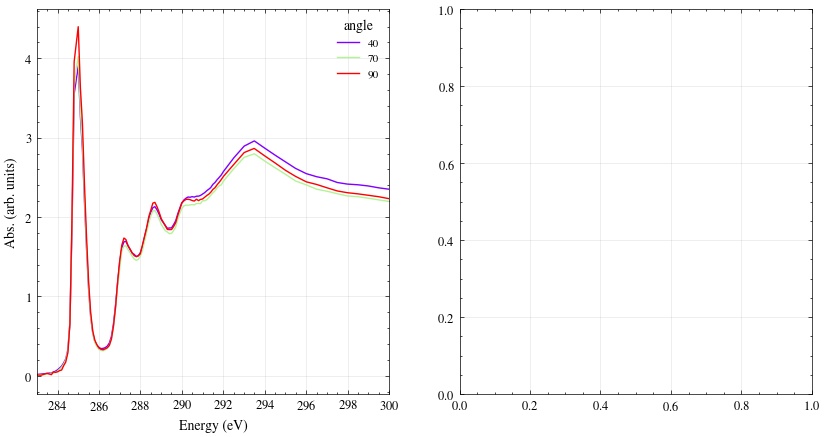

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use(["science", "no-latex"])

def set_plotting_defaults():
    """
    Set matplotlib rcParams for fontsize and grid defaults.

    This function configures:
    - Font sizes for labels, ticks, legend, and titles
    - Grid appearance (alpha, linestyle, linewidth)
    - General figure aesthetics

    Examples
    --------
    >>> from src.utils.helpers.plotting_helper import set_plotting_defaults
    >>> set_plotting_defaults()
    >>> plt.plot([1, 2, 3], [1, 4, 9])
    >>> plt.show()
    """
    plt.rcParams.update(
        {
            "text.usetex": False,
            "font.size": 10,
            "axes.labelsize": 10,
            "axes.titlesize": 11,
            "xtick.labelsize": 9,
            "ytick.labelsize": 9,
            "legend.fontsize": 8,
            "figure.titlesize": 12,
            "grid.alpha": 0.3,
            "grid.linestyle": "-",
            "grid.linewidth": 0.5,
            "axes.grid": True,
            "axes.grid.axis": "both",
        }
    )

set_plotting_defaults()

fig, ax = plt.subplots(
    ncols=2,
    figsize=(10, 5),
)

sns.lineplot(
    data=df,
    x="energy",
    y="absorbance",
    hue="angle",
    legend=True,
    palette="rainbow",
    ax=ax[0]
)
ax[0].set_xlabel("Energy (eV)")
ax[0].set_ylabel("Abs. (arb. units)")
ax[0].set_xlim(283, 300)


In [ ]:
import matplotlib.pyplot as plt
from scipy.special import erf


def gaussian(E, w, E_0, A):
    # Ensure positive width
    if w <= 0:
        return np.zeros_like(E)
    sigma = w / (2 * np.sqrt(2 * np.log(2)))
    norm = A
    return norm * np.exp(-((E - E_0) ** 2) / (2 * sigma ** 2))

def peak_fit(energy, *params):
    num_peaks = 5  # Number of peaks
    expected_len = 4 + num_peaks * 3
    if len(params) != expected_len:
        raise ValueError(
            f"Expected {expected_len} parameters (4 for edge+decay, then {num_peaks}*3 for peaks), got {len(params)}"
        )
    # Edge and decay
    height, edge_pos, edge_width, decay_const = params[:4]
    if edge_width <= 0:
        edge_width = 1e-5  # Prevent division by zero or negatives
    step_transition = height * 0.5 * (1 + erf((energy - edge_pos) / edge_width))
    decay = np.ones_like(energy)
    decay_mask = energy > edge_pos
    decay[decay_mask] = np.exp(-decay_const * (energy[decay_mask] - edge_pos))
    spectrum = step_transition * decay

    # Add peaks
    peaks = params[4:]
    for i in range(num_peaks):
        w, E_0, A = peaks[i*3:(i+1)*3]
        # Only add non-trivial peaks (width>0, amplitude!=0)
        if w > 0 and abs(A) > 0:
            spectrum += gaussian(energy, w, E_0, A)
    return spectrum


In [191]:

energy = np.linspace(283, 300, 1000)

# Initial parameters - now 6 peaks, inserting an extra peak between peak 1 (285.01) and 2 (287.17)
# We'll add the new peak at 286.09 eV, with width 0.42, amplitude 0.4 (can adjust as needed)
p0 = [
    1.1799,    # NEXAFS_EDGE: norm (height)
    289.78,    # NEXAFS_EDGE: edge position
    0.68074,   # NEXAFS_EDGE: erf width
    0.0028455, # exponential decay constant (loaded from parameter file)

    # Peak 1
    0.35877, 285.01, 4.3144,
    # Peak 3
    0.41166, 287.17, 0.94996,
    # Peak 4
    1.3867, 288.65, 1.7005,
    # Peak 5
    2.3432, 293.06, 0.84016,
    # Peak 6
    8.7234, 298.62, 1.19,
]

# Bounds for all params: lower and upper, updated for new peak (8 peaks)
bounds_lower = [
    0,        # norm >= 0
    283,      # edge pos >= min energy
    0.01,     # erf width > 0
    0,        # decay constant >= 0

    # Peak 1
    0.01, 284.5, 0,
    # Peak 3 (287.17)
    0.01, 286.7, 0,
    # Peak 4 (288.65)
    1.3, 287.18, 0,
    # Peak 5 (293.06)
    0.01, 288.66, 0,
    # Peak 6 (298.62)
    0.01, 293.07, 0,
]

bounds_upper = [
    10,       # norm
    300,      # edge pos
    10,       # erf width
    1,        # decay constant

    # Peak 1
    3, 285.6, 10,
    # Peak 3
    3, 288.2, 10,
    # Peak 4
    10, 293.0, 10,
    # Peak 5
    10, 298.6, 10,
    # Peak 6
    20, 300, 10,
]

(283.0, 300.0)

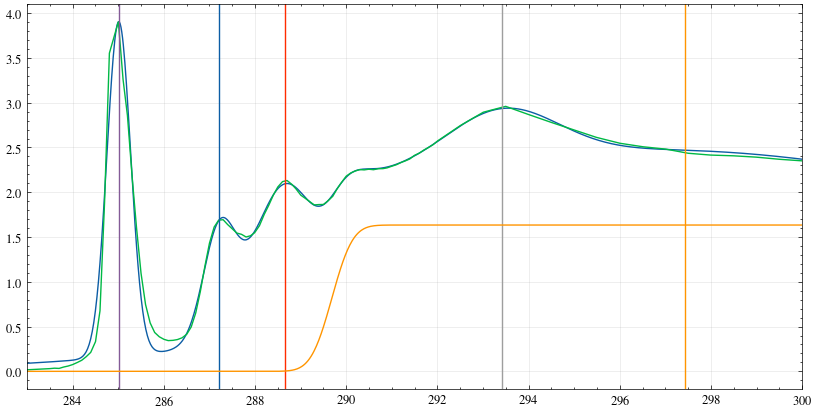

In [192]:
from scipy.optimize import curve_fit

# fit angle = 70 to the multi-peak function
dataset = df[df["angle"] == 40]

popt, pcov = curve_fit(
    peak_fit,
    dataset["energy"],
    dataset["absorbance"],
    p0=p0,
    bounds=(bounds_lower, bounds_upper)
)

fig, ax = plt.subplots(
    figsize=(10, 5),
)

ax.plot(energy, peak_fit(energy, *popt))
ax.plot(dataset["energy"], dataset["absorbance"])
# for each peak, draw a vertical line at the peak position
for i in range(4, len(popt), 3):
    ax.axvline(popt[i+1], color=f"C{i}")

# plot the step
ax.plot(energy, (
    popt[0] * 0.5 * (1 + erf((energy - popt[1]) / popt[2]))
))
ax.set_xlim(283, 300)

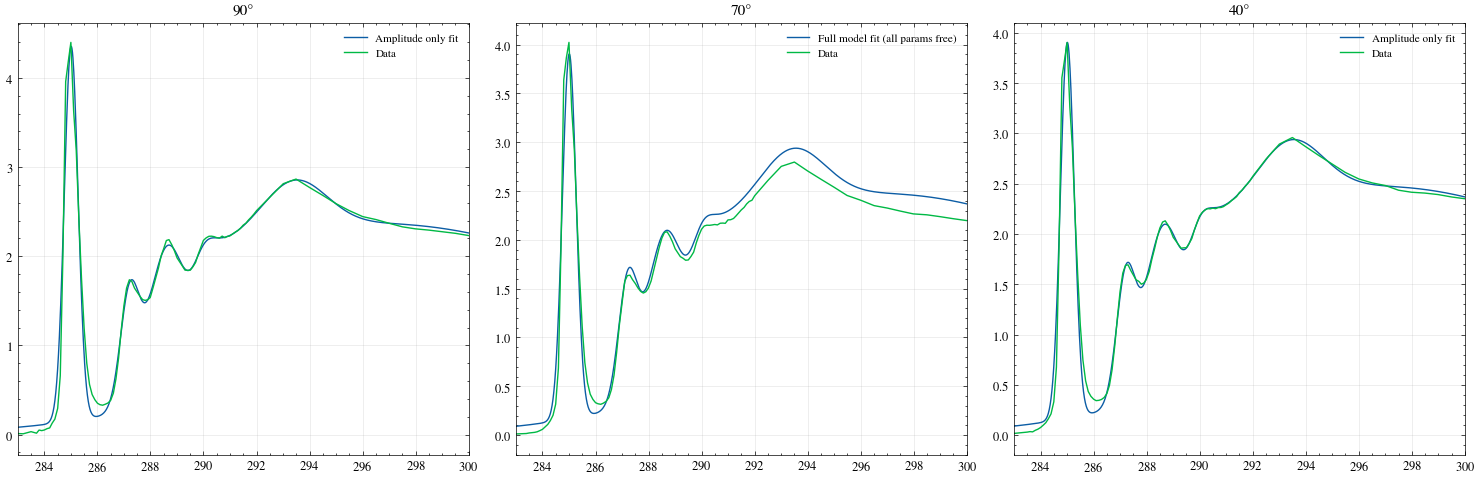

In [194]:
# First, fit the 70 degree data using the full model to get optimized positions and widths (and amplitudes)
from scipy.optimize import curve_fit
from uncertainties import ufloat

angles = df["angle"].unique()

# Dictionary to save peak amplitudes and their uncertainties for each angle
amplitudes_by_angle = {}

# --- 1. Fit full model to angle = 70 ---
dataset_70 = df[df["angle"] == 40]

popt_70, pcov_70 = curve_fit(
    peak_fit,
    dataset_70["energy"],
    dataset_70["absorbance"],
    p0=p0,
    bounds=(bounds_lower, bounds_upper)
)

# Save amplitudes & their uncertainties for 70 deg
n_peaks = len(popt_70) // 3
amps_70 = [ufloat(popt_70[3*i], np.sqrt(pcov_70[3*i, 3*i])) for i in range(n_peaks)]
amplitudes_by_angle[70] = amps_70

# --- 2. For other angles, fit only amplitudes, with positions and widths fixed from popt_70 ---
def make_amp_only_func(fixed_params):
    def fit_func(energy, *amps):
        # amps is array of amplitudes, replace amp_i in fixed_params
        params = fixed_params.copy()
        for i, amp in enumerate(amps):
            params[3*i] = amp
        return peak_fit(energy, *params)
    return fit_func

# Get fixed positions/widths from popt_70, only vary amplitudes
fixed_params = list(popt_70)
p0_amps = [popt_70[i] for i in range(0, len(popt_70), 3)]
bounds_lower_amps = [bounds_lower[i] for i in range(0, len(bounds_lower), 3)]
bounds_upper_amps = [bounds_upper[i] for i in range(0, len(bounds_upper), 3)]

# Plot for all angles
fig, axs = plt.subplots(1, len(angles), figsize=(15, 5), sharex=True)
if len(angles) == 1:
    axs = [axs]

for idx, angle in enumerate(angles):
    dataset = df[df["angle"] == angle]
    ax = axs[idx]

    # Check for empty dataset - helps avoid ValueError: `ydata` must not be empty!
    if len(dataset) == 0 or len(dataset["energy"]) == 0 or len(dataset["absorbance"]) == 0:
        ax.set_title(f"{angle}° (no data)")
        ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
        ax.set_xlim(283, 300)
        # Save as None for missing
        amplitudes_by_angle[angle] = None
        continue

    if angle == 70:
        # Full fit already performed above
        fit_y = peak_fit(energy, *popt_70)
        ax.plot(energy, fit_y, label="Full model fit (all params free)")
        fit_peaks = popt_70[::3]
        fit_positions = [popt_70[3*i+1] for i in range(n_peaks)]
    else:
        # Amplitude-only fit using fixed positions/widths from 70 fit
        amp_only_func = make_amp_only_func(fixed_params)
        try:
            popt_amps, pcov_amps = curve_fit(
                amp_only_func,
                dataset["energy"],
                dataset["absorbance"],
                p0=p0_amps,
                bounds=(bounds_lower_amps, bounds_upper_amps)
            )
            fit_y = amp_only_func(energy, *popt_amps)
            ax.plot(energy, fit_y, label="Amplitude only fit")
            fit_peaks = popt_amps
            fit_positions = [fixed_params[3*i+1] for i in range(n_peaks)]
            # Save amplitudes and uncertainties (sqrt(diag(cov)))
            amps_this = [
                ufloat(popt_amps[i], np.sqrt(pcov_amps[i, i]) if pcov_amps.shape[0] > i else np.nan)
                for i in range(n_peaks)
            ]
            amplitudes_by_angle[angle] = amps_this
        except ValueError as e:
            ax.set_title(f"{angle}° (fit error)")
            ax.text(0.5, 0.5, f"Fit failed:\n{e}", ha="center", va="center", transform=ax.transAxes)
            fit_positions = []
            # Save as None for failed fit
            amplitudes_by_angle[angle] = None

    ax.plot(dataset["energy"], dataset["absorbance"], label="Data")
    ax.set_xlim(283, 300)
    ax.set_title(f"{angle}°")
    ax.legend()
plt.tight_layout()
plt.show()

# amplitudes_by_angle now holds the fitted amplitudes and their uncertainties for each angle.

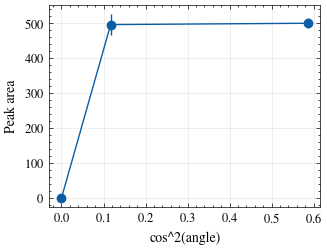

In [202]:

amps = {
    "angle": angles,
    "cos^2(angle)": [np.cos(np.deg2rad(ang))**2 for ang in angles],
    "amplitude": [amplitudes_by_angle[ang][0] for ang in angles],
}

# Compute the peak width as ufloat
amps["width"] = [
    ufloat(popt_70[3*i+2], np.sqrt(pcov_70[3*i+2, 3*i+2])) for i in range(n_peaks)
]

# Correct area calculation for a Gaussian where width is FWHM:
# Area = amplitude * FWHM * sqrt(pi / (4 * ln(2)))
amps["area"] = [
    amp * width * np.sqrt(np.pi / (4 * np.log(2))) for amp, width in zip(amps["amplitude"], amps["width"], strict=False)
]

# Extract nominal value and std dev using the uncertainties package
amps["area_n"] = [a.n for a in amps["area"]]
amps["area_unc"] = [a.s for a in amps["area"]]

plt.errorbar(amps["cos^2(angle)"], amps["area_n"], yerr=amps["area_unc"], fmt='o-')
plt.xlabel("cos^2(angle)")
plt.ylabel("Peak area")
plt.show()
